# **Deeploc 2.1**

2025 겨울 URP / 문서연, 김대현, 권효재


---


여기서부턴 Deeploc 2.1과 같은 구조로 학습을 진행!


---


개선/공부 필요(2026_01_18):

---

# **라이브러리 설명**

# torch
Pytorch 라이프러리 패키지


* torch.autograd: 자동 미분을 위한 함수가 포함됨(ex. enable/no_grad: 자동 미분 on/off, Function: 자체 미분 함수 정의 클래스)
* torch.nn: 신경망 구축을 위한 기본 데이터 구조/레이어(RNN/LSTM)/활성화 함수(ReLU)/손실 함수(MSELoss) 포함됨
* torch.optim: 확률적 경사 하강법(Stochastic Gradient Descent, SGD) 중심의 파라미터 옵티마이저 알고리즘
* torch.utils.data: SDG 반복연산 시에 사용하는 미니배치 유틸리티 포함됨
* torch.onnx: ONNX(Open Neural Network Exchange) 포맷으로 모델 export 할 때 사용

In [10]:
# 필요 라이브러리 설치 및 import
!pip install -q torch pandas numpy safetensors optuna lmdb

# from torchvision.ops import sigmoid_focal_loss as FocalLoss

import io
import gc
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import math
import lmdb
import pickle

from tqdm import tqdm
from safetensors import safe_open
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from scipy.ndimage import gaussian_filter1d

In [4]:
# <저장소 설정>

# Colab 환경
from google.colab import drive

drive.mount("/content/drive")
SAVE_PATH = (
   "/content/drive/MyDrive/Github/Mprotein_hydrophobic/dataset/lmdb"
)

# 로컬 환경
#SAVE_PATH = '../ESMC_embedding_safetensors'

os.makedirs(SAVE_PATH, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
env = lmdb.open(SAVE_PATH, readonly=True)

In [13]:
# 데이터셋 클래스 정의
class LMDBDataset_K_CV(Dataset):
    # 데이터셋 전처리
    def __init__(self, K_CV, test_k, save_path, is_train = True):
        if is_train:
            self.train_part = [i for i in range(K_CV) if i != test_k]
        else:
            self.train_part = [test_k]
        #기본 저장 경로: save_path
        self.save_path = save_path
        #lmdb에서 key list 호출
        self.env = lmdb.open(self.save_path, readonly=True, lock=False, readahead=False, meminit=False)
        with self.env.begin() as txn:
            self.keys = pickle.loads(txn.get(b'__keys__'))

    # 몇개있는지 알려줘야함
    def __len__(self):
        return len(self.keys)

    # 데이터셋 샘플 1개 가져오기
    def __getitem__(self, idx):
        key = self.keys[idx]
        with self.env.begin() as txn:
            data = torch.load(io.BytesIO(txn.get(key.encode())))
        return data['embedding'], data['target']

# c = LMDBDataset_K_CV(4, 0, SAVE_PATH)
# a, b = c[0]
# print(a)
# print(b)

In [15]:
import time
c = LMDBDataset_K_CV(4, 0, SAVE_PATH)

# 테스트1: 순차 접근
st = time.time()
for i in range(100): c[i]
print(f"순차 100개: {time.time()-st:.2f}s")

# 테스트2: 셔플 접근
import random; random.shuffle(indices := list(range(len(c))))
st = time.time()
for i in indices[:100]: c[i]
print(f"셔플 100개: {time.time()-st:.2f}s")

순차 100개: 52.44s


KeyboardInterrupt: 

In [12]:
def padding_collate_fn(batch):
    #임베딩/타겟 분리
    embeddings = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    # 2. 임베딩 패딩
    padded_embeddings = pad_sequence(embeddings, batch_first=True, padding_value=0)
    targets = torch.stack(targets)
    return padded_embeddings, targets

In [ ]:
# 앞에서 Layer normalization 해준걸 인풋으로 받는다고 가정
class MultiheadAttentionPooling(nn.Module):
    def __init__(self, attn_dim=128, heads_nums=2, kernel_size=5):
        super().__init__()
        self.attn_dim = attn_dim
        # 우선은,, 멀티헤드로 구현을 한다
        self.heads_nums = heads_nums
        # 멀티헤드의 디멘션은 전체 디멘션을 헤드 개수로 나눈것
        # 이거때문에 헤드 개수를 잘 나눠지도록(?) 설정함 보통
        self.head_dim = attn_dim // heads_nums

        # Q, K = V 만들기
        # Q : learnable Query, 먼저 (1, 1, attn_dim) 에 해당하는 빈 벡터 > xavier_uniform_ 하면 입출력 고려해서 난수생성 가능
        self.query = nn.Parameter(torch.empty(1, 1, attn_dim))
        nn.init.xavier_uniform_(self.query.data)
        self.w_kv = nn.Linear(
            attn_dim, attn_dim
        )  # 입력/출력 크기가 attn_dim인 Linear FC를 수행하는 모듈 // key value 짜피 같으니까 이걸로 한번에 할거고 논문도 그렇게 했는데 둘이 따로 초기화한다면? 즉 파라미터가 두개라면..?

    def forward(self, x):
        # 입력으로 받을 형태: (batch_size, sequence_length, attn_dim)
        batch_size, sequence_length, _ = x.shape

        # 배치 사이즈에 맞게 복제: 각 배치 샘플 전부 같은 쿼리 파라미터 공유
        # attn_dim을 헤드별로 쪼갬()
        # 헤드별로 계산할거라서 헤드를 앞으로 뺌
        Q = (
            self.query.repeat(batch_size, 1, 1)
            .view(batch_size, 1, self.heads_nums, self.head_dim)
            .transpose(1, 2)
        )
        K = (
            self.w_kv(x)
            .view(batch_size, sequence_length, self.heads_nums, self.head_dim)
            .transpose(1, 2)
        )
        V = (
            self.w_kv(x)
            .view(batch_size, sequence_length, self.heads_nums, self.head_dim)
            .transpose(1, 2)
        )
        # 셋다 (batch_size, head_nums, sequence_length(Q:1; per token), head_dim)
        # print(Q)
        # print(K)
        # print(V)
        # 행렬곱 > Attention Scalar score 구함!
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        # print(f"어텐션 Score: {scores.shape}")
        # Conv1d 가우시안 필터
        scores_c1d_gaussian = scores

        # Softmax 적용
        attn_weights = F.softmax(scores_c1d_gaussian, dim=-1)
        # print(f"어텐션 Weights: {attn_weights.shape}")

        # 행렬곱 > weighted attention
        attnpooled_nosum = torch.matmul(attn_weights, V)
        # print(f"어텐션 Pooling (합하기 전): {attnpooled_nosum.shape}")

        # 가중합을 위해 (batch_size, head_nums, 1, head_dim) 순서니까
        # 1 없애고 reshape로 head concat해주기
        attentionpooled = attnpooled_nosum.squeeze(2).reshape(batch_size, self.attn_dim)
        # print(f"어텐션 Pooling: {attentionpooled.shape}")

        return attentionpooled

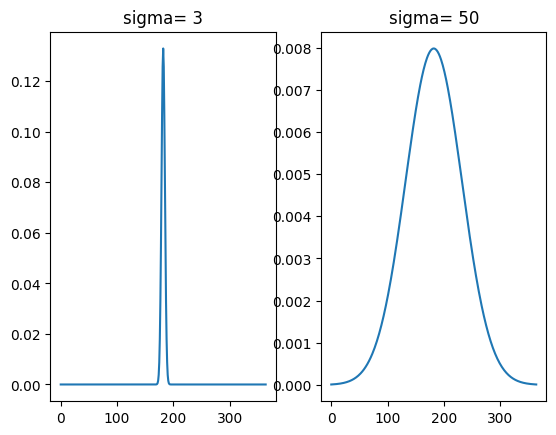

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

sigma1 = 3
sigma2 = 50

def gaussian_filter1d(size,sigma):
    filter_range = np.linspace(-int(size/2),int(size/2),size)
    gaussian_filter = [1 / (sigma * np.sqrt(2*np.pi)) * np.exp(-x**2/(2*sigma**2)) for x in filter_range]
    return gaussian_filter

fig,ax = plt.subplots(1,2)
ax[0].plot(gaussian_filter1d(size=365,sigma=sigma1))
ax[0].set_title(f'sigma= {sigma1}')
ax[1].plot(gaussian_filter1d(size=365,sigma=sigma2))
ax[1].set_title(f'sigma= {sigma2}')
plt.show()

In [ ]:
class Deeploc2_1(nn.Module):
    def __init__(self, heads_nums, embedding_dim, attn_dim, output_dim = 4, hidden_dim = 0):
        super().__init__()
        self.input_layer_normalization = nn.LayerNorm(embedding_dim)
        self.input_linear_fc = nn.Linear(embedding_dim, attn_dim)
        self.attention_layer_normalization = nn.LayerNorm(attn_dim)
        self.attention_head = MultiheadAttentionPooling(attn_dim=attn_dim, heads_nums=heads_nums)
        self.dropout = nn.Dropout(0.1)
        if hidden_dim == 0:
          hidden_dim = attn_dim
        self.output_linear_fc = nn.Linear(hidden_dim, output_dim)  # mlp층 쌓으면 attn_dim 아니고 hidden_dim 됨 이거 나중에 고쳐야할듯
    def forward(self, x):
        #layer normalization, 선형층 통과 > embedding dim에서 attn dim으로,,
        x = self.input_layer_normalization(x)
        x = self.input_linear_fc(x)
        #attention head 통과 > (batch_size, attn_dim)
        x = self.attention_layer_normalization(x)
        x = self.attention_head(x)
        x = self.dropout(x)
        #선형층 통과(분류기) > attn dim에서 4개로,,
        x = self.output_linear_fc(x)
        return x

NameError: name 'nn' is not defined

In [ ]:
# @title
def sigmoid_focal_loss(
    inputs: torch.Tensor,
    targets: torch.Tensor,
    alpha: float = 0.25,
    gamma: float = 2,
    reduction: str = "none",
) -> torch.Tensor:

    if not (0 <= alpha <= 1) and alpha != -1:
        raise ValueError(
            f"Invalid alpha value: {alpha}. alpha must be in the range [0,1] or -1 for ignore."
        )

    p = torch.sigmoid(inputs)
    ce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction="none")
    p_t = p * targets + (1 - p) * (1 - targets)
    loss = ce_loss * ((1 - p_t) ** gamma)

    if alpha >= 0:
        alpha_t = alpha * targets + (1 - alpha) * (1 - targets)
        loss = alpha_t * loss

    # Check reduction option and return loss accordingly
    if reduction == "none":
        pass
    elif reduction == "mean":
        loss = loss.mean()
    elif reduction == "sum":
        loss = loss.sum()
    else:
        raise ValueError(
            f"Invalid Value for arg 'reduction': '{reduction} \n Supported reduction modes: 'none', 'mean', 'sum'"
        )
    return loss

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
K_CV = 4
NUM_EPOCHS = 2

In [ ]:
# Dataset 생성 후 바로 추가
print("=== 데이터셋 로딩 초기화 중 (file_handles 채우기) ===")
DATALOADER = DataLoader(DATASET, batch_size=5, shuffle=False, num_workers=0, collate_fn=padding_collate_fn)

# 전체 순회: 모든 key 로딩 → 캐싱 완료
preloader = tqdm(total=len(DATASET), desc="Pre-loading Dataset", unit="samples")
for batch_idx, (embeddings, targets) in enumerate(DATALOADER):
    # 실제 데이터 안 쓰고 버리기
    samples_loaded = (batch_idx + 1) * 5  # 배치 크기만큼 로딩됨
    preloader.update(samples_loaded)
preloader.close()

print("✅ 데이터셋 로딩 완료! 이제 훈련 시작 (I/O 거의 없음)")

=== 데이터셋 로딩 초기화 중 (file_handles 채우기) ===


Pre-loading Dataset: 29764875samples [01:24, 353469.65samples/s]

✅ 데이터셋 로딩 완료! 이제 훈련 시작 (I/O 거의 없음)


In [ ]:
for i in range(K_CV):
    #초기화
    DATASET = K_CV_NotLazy(K_CV, 0, SAVE_PATH)
    DATALOADER = DataLoader(DATASET, batch_size = 5, shuffle = True, num_workers = 2, collate_fn = padding_collate_fn)
    MODEL = Deeploc2_1(embedding_dim=1152, attn_dim=128, output_dim=4, heads_nums=2).to(DEVICE)
    OPTIMIZER = AdamW(MODEL.parameters(), lr=1e-4)

    for epoch in range(NUM_EPOCHS):
            MODEL.train()

            for embeddings, targets in tqdm(DATALOADER):
                OPTIMIZER.zero_grad()
                embeddings, targets = embeddings.to(DEVICE), targets.to(DEVICE)

                outputs = MODEL(embeddings)
                loss_value = sigmoid_focal_loss(outputs, targets, alpha=0.25, gamma=2, reduction="mean")
                loss_value.backward()
                OPTIMIZER.step()

  7%|▋         | 237/3450 [00:05<01:12, 44.13it/s]


KeyboardInterrupt: 

In [ ]:
    # with torch.no_grad(): # 평가 땐 기울기 계산 비활성화 (메모리 절약)
    #     for inputs, labels in val_dataloader: # 검증용 로더 (없으면 생략 가능)
    #         inputs = inputs.float().to(DEVICE)
    #         labels = labels.long().to(DEVICE)

    #         outputs = model(inputs)
    #         loss = criterion(outputs, labels)

    #         val_loss += loss.item()
    #         _, predicted = torch.max(outputs, 1)
    #         val_total += labels.size(0)
    #         val_correct += (predicted == labels).sum().item()

    # val_loss = val_loss / len(val_dataloader)
    # val_acc = 100 * val_correct / val_total

    # print(f"Epoch [{epoch+1}/{num_epochs}] "
    #       f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
    #       f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

In [ ]:
# 데이터셋 클래스 정의
class K_CV_MultipleFiles_Dataset(Dataset):
    # 데이터셋 전처리
    def __init__(self, K_CV, validation_k, save_path, is_train = True):
        #훈련 > K개의 데이터셋 중 validation_k 제외한 리스트 생성
        #테스트 > validation_k만 생성
        if is_train:
            self.train_part = [i for i in range(K_CV) if i != validation_k]
        else:
            self.train_part = [validation_k]

        #기본 저장 경로: save_path
        self.save_path = save_path

        #x와 y는 같은 key(ACC) 공유
        #y로부터 총합 key list를 만들 예정
        #key가 x의 어떤 파티션에 있는지 불러오기 위해 key와 x 파일 주소가 저장된 일종의 주소록 딕셔너리 생성
        #반복문을 돌며 총합 targets 딕셔너리 생성
        self.key_list = []
        self.targets = {}
        self.keys_to_x = {}
        self.file_handels = {}

        for i in self.train_part:
            #x, y 경로 설정
            path_x = os.path.join(self.save_path, f'embeddings_part_{i}.safetensors')
            path_y = os.path.join(self.save_path, f'target_part_{i}.pt')

            ##타겟 파일
            #타겟 파일 로드, 딕셔너리 업데이트, keys 리스트 가져오기
            y = torch.load(path_y, weights_only = False)
            self.targets.update(y)
            key_list_k = list(y.keys())
            self.key_list.extend(key_list_k)

            ##딕셔너리 주소 저장
            for key in key_list_k:
                self.keys_to_x[key] = path_x

        #재현성을 위해 정렬
        self.key_list.sort()

    # 몇개있는지 알려줘야함
    def __len__(self):
        return len(self.key_list)

    # 데이터셋 샘플 1개 가져오기
    def __getitem__(self, idx):
        #리스트에서 idx번째 key 호출
        key = self.key_list[idx]

        #1. 이 키가 위치한 파일이 어디인지 주소보고 확인
        path_x_k = self.keys_to_x[key]

        #2. 파일 핸들 열려있는지 확인, 안 열려있으면 열어서 보관함에 등록
        if path_x_k not in self.file_handels:
            self.file_handels[path_x_k] = safe_open(path_x_k, framework="pt", device='cpu')

        #3. 보관함에서 핸들 꺼내오기
        f = self.file_handels[path_x_k]

        embedding = f.get_tensor(key).clone()
        embedding = embedding.squeeze(0)

        target_numpy = self.targets[key]
        target = torch.from_numpy(target_numpy).squeeze(0).float()

        return embedding, target
# 작동 테스트
# c = K_CV_MultipleFiles_Dataset(4, 0, SAVE_PATH)
# a, b = c[0]
# print(a)
# print(b)

In [ ]:
# 데이터셋 클래스 정의
# 훈련 > K개의 데이터셋 중 validation_k 제외한 리스트 생성
# 테스트 > validation_k만 생성
class KCVDataset(Dataset):
    # 초기화: 데이터셋 전처리
    def __init__(self, K_CV, validation_k, save_path, is_train = True):
        if is_train:
            self.train_part = [i for i in range(K_CV) if i != validation_k]
        else:
            self.train_part = [validation_k]

        #기본 저장 경로: save_path
        self.save_path = save_path

        #반복문 > 파일 합 targets/embeddings 딕셔너리
        self.targets = {}
        self.embeddings = {}
        for i in self.train_part:
            #x, y 경로 설정
            path_x = os.path.join(self.save_path, f'embeddings_part_{i}.safetensors')
            path_y = os.path.join(self.save_path, f'target_part_{i}.pt')

            #타겟 파일 로드
            y = torch.load(path_y, weights_only = False)
            self.targets.update(y)

            #임베딩 파일
            with safe_open(path_x, framework="pt", device='cpu') as f:
                x = {k: f.get_tensor(k).squeeze() for k in f.keys()}
                self.embeddings.update(x)

        #키 리스트 반환
        self.key_list = list(self.targets)

    # 몇개있는지 알려줘야함
    def __len__(self):
        return len(self.key_list)

    # 데이터셋 샘플 1개 가져오기
    def __getitem__(self, idx):
        #리스트에서 idx번째 key 호출
        key = self.key_list[idx]

        #키에 해당하는 임베딩, 타겟 불러오기
        embedding = self.embeddings[key].clone()
        target = torch.from_numpy(self.targets[key]).squeeze(0).float()

        return embedding, target
# 작동 테스트
# c = K_CV_MultipleFiles_Dataset(4, 0, SAVE_PATH)
# a, b = c[0]
# print(a)
# print(b)